# Notebook III - Climatic Constraints

<hr>
This module uses various yield reduction factors to apply the obtained maximum attainable yield from Module 2 to consider the constraint effects separately from Module II. This modules works with two separate python look-up scripts ALL_REDUCTION_FACTORS_IRR and ALL_REDUCTION_FACTORS_RAIN which must be manually edited for crop/LUT specific reduction factors.

Prepared by Geoinformatics Center, AIT
<hr>

### Google drive connection
In this step, we will connect to Google Drive service and mount the drive where we will start our PyAEZ project

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

Then, installing any additional python packages that required to run PyAEZ.
If working on your own PC/machine, these additional installation will vary depending on what is already installed in your Python library. 

In [ ]:
# 'Installing neccessary packages'
# !pip install gdal

## Importing Libraries

In [1]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import xarray as xr

try:
    from osgeo import gdal
except:
    import gdal
import sys

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 


In [2]:
from pyaez_main import initialize_climatic_constraints

work_dir = r'/workspaces/Python-AEZ-FAO'  # Please change this to your working directory
country_name = 'togo'
country_mask_name = 'togo_rasterized.tif'
elevation_filename = 'togo_elevation_resampled_clipped.tif'
year = '1980'

clim_con = initialize_climatic_constraints(work_dir, country_name, country_mask_name, elevation_filename, year)

Available crops:
1. maize
2. rice
3. soybean
4. sugarcane
5. cassava
6. cocoa
7. coffee
8. cashew


Select a crop by number:  5


You selected: cassava


Computed rainfed yield for cassava using ./data_input/input_module3/Cassava_High_rf_lst.xlsx


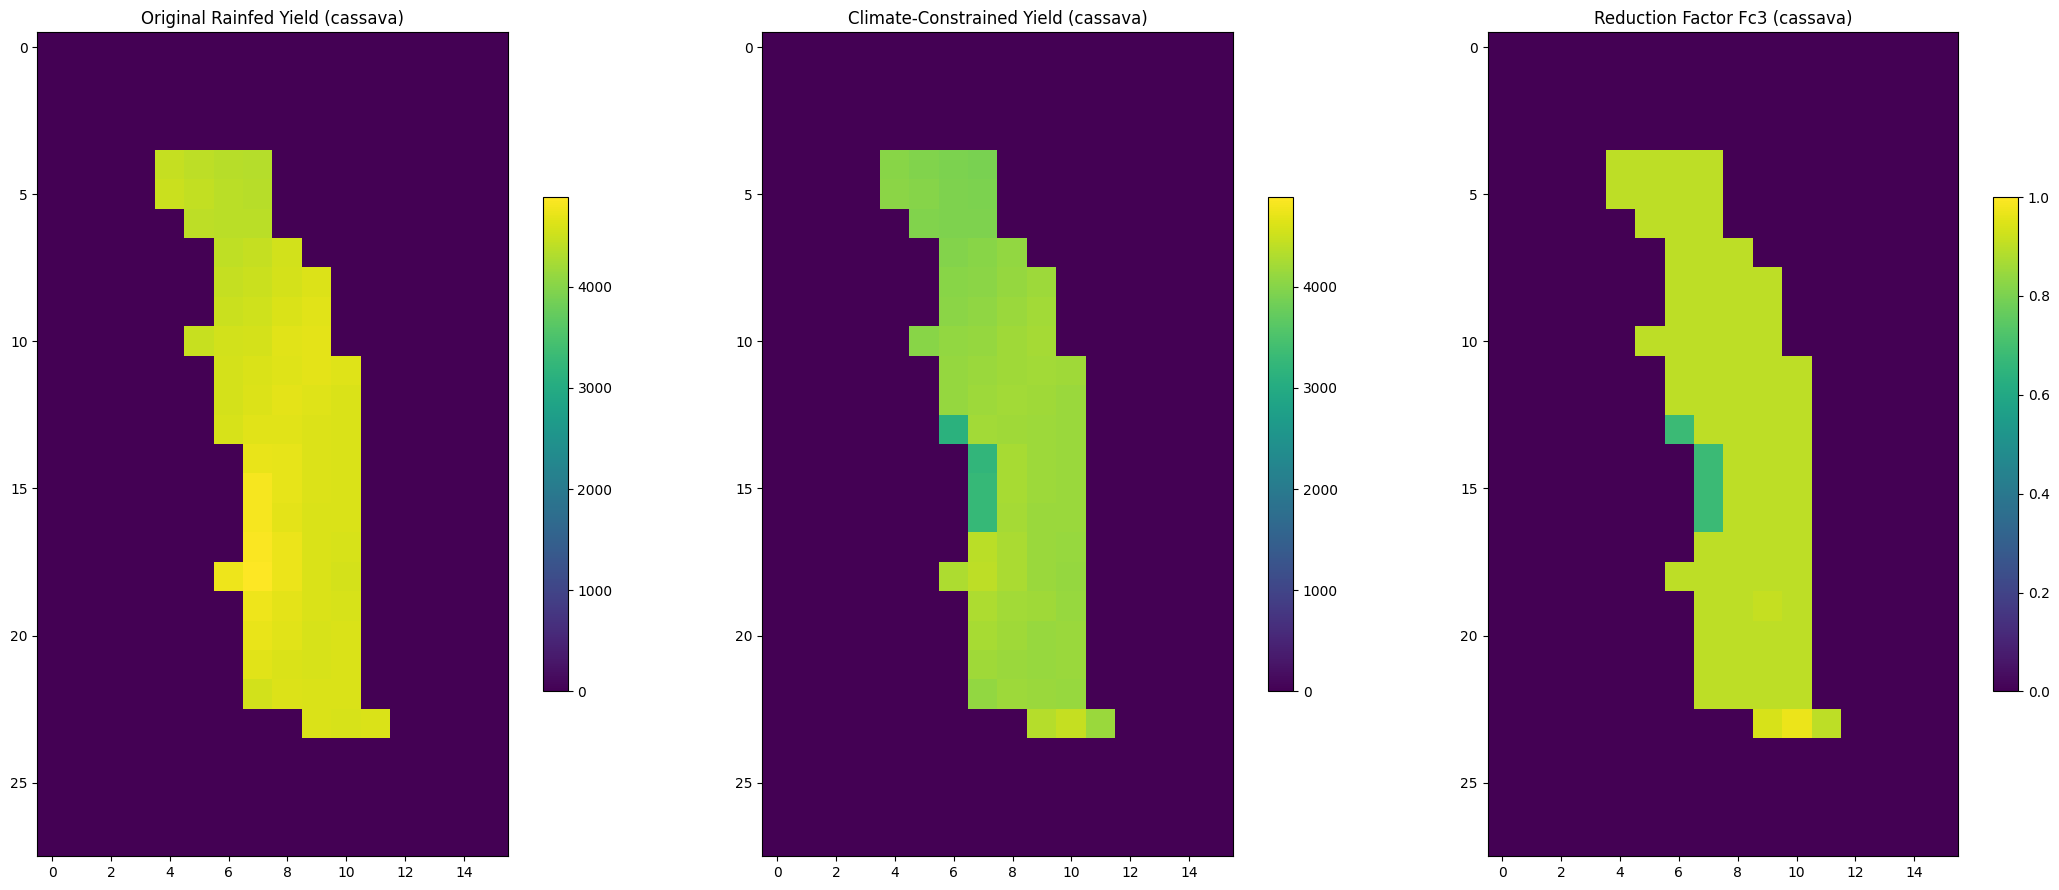

In [3]:
from pyaez_main import compute_yield

condition_type = 'rainfed'
clim_yield_rain, fc3_rain = compute_yield(clim_con, condition_type, work_dir, country_name, year, plot_results=True)

Computed irrigated yield for cassava using ./data_input/input_module3/Cassava_High_ir_lst.xlsx


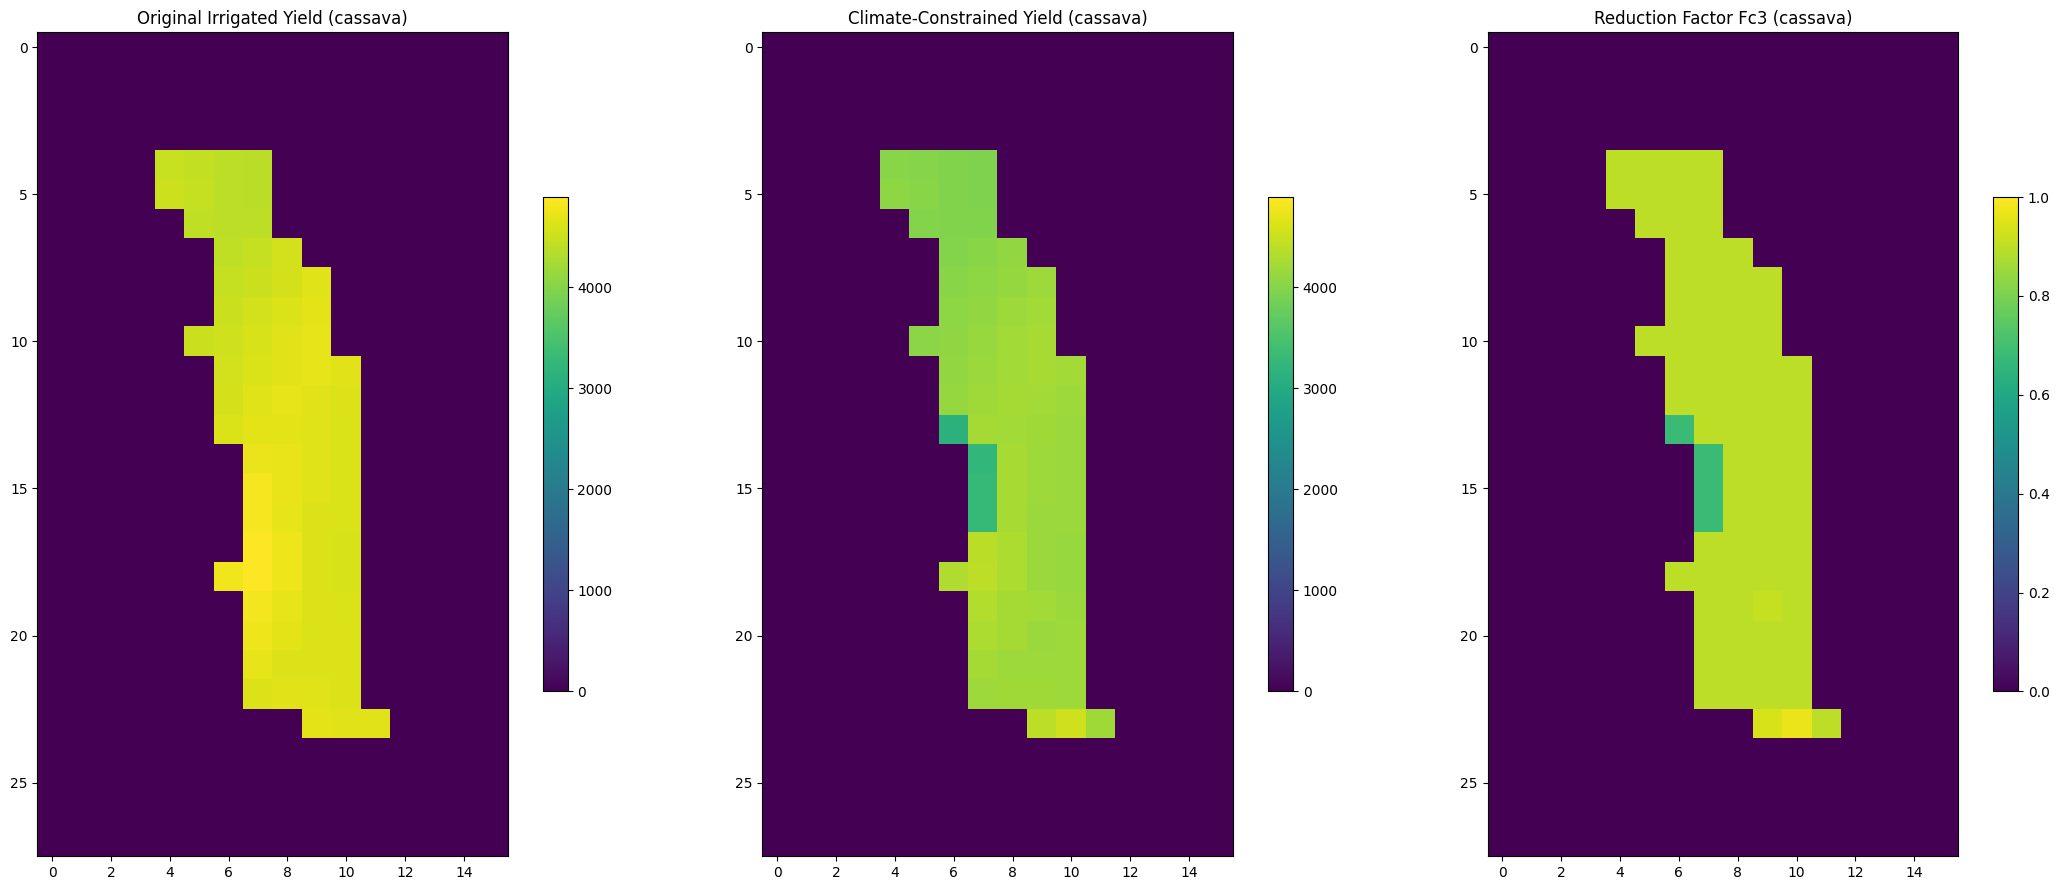

In [4]:
condition_type = 'irrigated'
clim_yield_irr, fc3_irr = compute_yield(clim_con, condition_type, work_dir, country_name, year, plot_results=True)

In [ ]:
'''save result (Rainfed Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{crop_name}_yld_rain_m3.tif', clim_yield_rain)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{crop_name}_rain.tif', fc3_rain)

In [ ]:
'''save result (Irrigated Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{crop_name}_yld_irr_m3.tif', clim_yield_irr)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{crop_name}_irr.tif', fc3_irr)
saveRaster(mask_path, r'./data_output/NB3/lgpagc.tif', clim_con.lgp_agc)

<hr>

### END OF MODULE 3: CLIMATIC CONSTRAINTS

<hr>